In [1]:
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import KNNImputer
import seaborn as sns

In [2]:
sns.set_theme(style='ticks')

In [3]:
class InitialProcessing:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.df_cleaned = None

    def load_and_transpose(self):
        self.df = pd.read_csv(self.file_path)
        self.df = self.df.transpose()
        new_header = self.df.iloc[0]
        self.df = self.df[1:]
        self.df.columns = new_header
        print(f"Original number of features: {len(self.df.columns)} features")

    def clean_data(self):
        self.df_cleaned = self.df.dropna(axis = 1, how = 'all')
        print(f"{self.__class__.__name__} keeping {len(self.df_cleaned.columns)} features")

    def patient_id(self):
        new_index = self.df_cleaned.index.str.split('-').str[:3].str.join('-')
        self.df_cleaned.index = new_index

    def process_data(self):
        self.load_and_transpose()
        self.clean_data()
        self.patient_id()
        return self.df_cleaned


class RemoveFeaturesWithZeros(BaseEstimator, TransformerMixin):

    def __init__(self, threshold: float, verbose: bool = False):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y = None):
        self.columns_ = X.columns[(X == 0).sum(axis=0) / len(X) < self.threshold]
        if self.verbose:
            print(f"{self.__class__.__name__} keeping {len(self.columns_)} features")
        return self

    def transform(self, X, y = None):
        transformed_X = X[self.columns_]
        return transformed_X


class RemoveFeaturesWithNaN(BaseEstimator, TransformerMixin):

    def __init__(self, threshold: float, verbose: bool = False):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y = None):
        self.columns_ = X.columns[(X.isna()).sum(axis=0) / len(X) < self.threshold]
        if self.verbose:
            print(f"{self.__class__.__name__} keeping {len(self.columns_)} features")
        return self

    def transform(self, X, y = None):
        transformed_X = X[self.columns_]
        return transformed_X


class RemoveFeaturesLowMAE(BaseEstimator, TransformerMixin):

    def __init__(self, percentage_to_keep: float, verbose: bool = False):
        self.percentage_to_keep = percentage_to_keep
        self.verbose = verbose

    def fit(self, X, y = None):
        X = X.apply(pd.to_numeric, errors='coerce')
        var = np.abs(X - np.median(X, axis = 0))
        var = np.median(var, axis = 0)
        var = pd.Series(var, index = X.columns)
        columns = var.nlargest(n = int(X.shape[1] * self.percentage_to_keep)).index
        self.columns_ = X.columns.intersection(columns)
        if self.verbose:
            print(f"{self.__class__.__name__} keeping {len(self.columns_)} features")
        return self

    def transform(self, X, y = None):
        transformed_X = X[self.columns_]
        return transformed_X


class RemoveCorrelatedFeatures(BaseEstimator, TransformerMixin):

    def __init__(self, threshold: float, verbose: bool = False):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y = None):
        X = X.apply(pd.to_numeric, errors='coerce')
        corr_mat = np.abs(np.corrcoef(X.T.values))
        np.fill_diagonal(corr_mat, 0)
        upper = pd.DataFrame(corr_mat, index = X.columns, columns = X.columns)
        self.columns_to_drop_ = upper.columns[(upper > self.threshold).any()]
        if self.verbose:
            print(f"{self.__class__.__name__} keeping {len(X.columns) - len(self.columns_to_drop_)} features")
        return self

    def transform(self, X, y=None):
        transformed_X = X.drop(columns = self.columns_to_drop_)
        return transformed_X


class Log2Transformation(FunctionTransformer):

    def __init__(self):
        super().__init__(lambda x: np.log2(1 + x.astype(float)))


class GeneMutations(BaseEstimator, TransformerMixin):
    def __init__(self, verbose: bool = False):
        self.verbose = verbose
        self.sorted_genes_ = []

    def fit(self, X, y = None):
        stacked_genes = X.stack()
        genes = stacked_genes.unique()
        gene_counts = stacked_genes.value_counts()
        self.sorted_genes_ = gene_counts.sort_values(ascending=False).index.tolist()
        if self.verbose:
            print(f"{self.__class__.__name__} has {len(self.sorted_genes_)} genes")
        return self

    def transform(self, X, y = None):
        transformed_X = pd.DataFrame(0, index = X.index, columns = self.sorted_genes_)
        for idx, row in X.iterrows():
            for gene in row.dropna():
                if gene in transformed_X.columns:
                    transformed_X.at[idx, gene] = 1
        return transformed_X
        

class ValueImputation(BaseEstimator, TransformerMixin):
    def __init__(self, verbose: bool = False):
        self.verbose = verbose
        self.imputer = KNNImputer()
        self.scaler = StandardScaler()

    def fit(self, X, y = None):
        X_scaled = self.scaler.fit_transform(X)
        self.imputer.fit(X_scaled)
        return self

    def transform(self, X, y = None):
        missing_values = X.isna().sum().sum()
        X_scaled = self.scaler.transform(X)
        X_imputed = self.imputer.transform(X_scaled)
        X_inverse = self.scaler.inverse_transform(X_imputed)
        transformed_X = pd.DataFrame(X_inverse, columns = X.columns, index = X.index)
        if self.verbose:
            print(f"{self.__class__.__name__} transforming {missing_values} values")
        return transformed_X

In [4]:
cna_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_GISTIC_Peaks-20160128.csv").process_data()
cna_data.columns = cna_data.loc['Descriptor']
for col in cna_data.columns:
    if cna_data.loc['type', col] == 'Deletion':
        cna_data[col] = cna_data[col].apply(lambda x: -x if isinstance(x, (int, float)) and x != 0 else x)
cna_new = cna_data[cna_data.index.str.contains('TCGA')]
cna_new = cna_new.apply(pd.to_numeric)
cna_new

Original number of features: 52 features
InitialProcessing keeping 52 features


Descriptor,1p36.11,1p34.2,1p12,1q21.3,2q14.3,2q36.2,3p21.31,3p12.2,3q26.2,4p16.3,...,18p11.31,18q11.2,18q21.2,19p13.3,19p13.2,19q13.2,19q13.33,20p11.23,21q11.2,22q13.31
TCGA-2J-AAB6,0,1,0,2,0,0,0,1,1,1,...,0,1,-1,0,0,2,0,2,0,0
TCGA-2J-AAB8,0,0,0,1,0,0,-1,0,2,0,...,0,1,-1,0,0,1,0,0,0,-1
TCGA-2J-AAB9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-2J-AABA,-1,0,0,0,0,0,0,0,0,0,...,0,0,-1,0,0,0,0,0,0,0
TCGA-2J-AABE,0,0,0,1,0,1,0,0,0,0,...,0,0,-1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,0,0,0,0,0,0,0,0,0,0,...,0,0,-1,0,0,0,-1,0,0,-1
TCGA-XN-A8T3,0,0,0,1,0,0,0,0,0,0,...,-1,0,-1,-1,-1,1,0,0,-1,-1
TCGA-YB-A89D,0,0,0,0,0,1,0,0,0,1,...,0,0,-1,0,0,1,0,1,-1,-1
TCGA-YY-A8LH,-1,0,0,1,0,0,-1,0,0,0,...,0,1,0,0,0,0,0,1,-1,-1


In [5]:
RPPA_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_RPPAArray-20160128.csv").process_data()
RPPA_pipeline = make_pipeline(
    RemoveFeaturesWithNaN(threshold=0.2, verbose=True),
    ValueImputation(verbose=True)
)
RPPA_new = RPPA_pipeline.fit_transform(RPPA_data)
RPPA_new

Original number of features: 195 features
InitialProcessing keeping 195 features
RemoveFeaturesWithNaN keeping 192 features
ValueImputation transforming 45 values


Unnamed: 0,14-3-3_beta,14-3-3_epsilon,14-3-3_zeta,4E-BP1,4E-BP1_pS65,4E-BP1_pT37_T46,4E-BP1_pT70,53BP1,A-Raf_pS299,ACC1,...,p27_pT157,p27_pT198,p38,p38_pT180_Y182,p53,p62-LCK-ligand,p70S6K,p70S6K_pT389,p90RSK,p90RSK_pT359_S363
TCGA-2J-AAB8,-0.155475,-0.033458,0.134824,-0.249239,-0.046843,-0.954384,-0.208913,-0.053876,0.130149,0.261683,...,-0.104697,-0.053968,0.008440,-0.380873,-0.129427,1.089494,0.167784,0.016613,0.308965,-0.073693
TCGA-2J-AAB9,0.009430,0.082697,0.055816,0.234152,-0.079005,-0.498472,0.009430,-0.250748,0.009430,-0.351898,...,0.009430,0.095870,-0.009557,-0.676698,0.194151,0.081150,-0.152487,-0.409575,0.009430,-0.206507
TCGA-2J-AABA,0.081741,0.041966,0.010881,-0.470501,-0.079825,-0.075485,0.004259,-0.409401,-0.025833,-0.994621,...,-0.174592,0.003343,0.152590,0.499674,0.152590,-0.103017,-0.162386,0.055573,-0.415766,-0.007253
TCGA-2J-AABF,0.160730,0.107695,0.196657,0.235793,0.235793,-0.029469,0.229316,-0.385111,0.156797,0.235793,...,0.222000,0.232202,0.016431,0.062777,-0.130066,-0.072009,-0.034951,0.032904,-0.324886,-0.217903
TCGA-2J-AABK,0.039741,0.123624,-0.151506,0.030981,0.206594,0.318087,0.048822,-0.019999,-0.088185,0.036935,...,0.021686,0.081243,0.017687,-0.374128,-0.018939,-0.154233,-0.019999,0.204215,0.322637,0.111336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUI,-0.038406,0.084706,-0.252875,0.333377,0.290843,0.088737,-0.180333,-0.302684,0.069992,0.037693,...,0.047335,0.184413,0.478657,-0.874790,0.132242,-0.895568,-0.217364,-0.035772,0.086241,-0.238106
TCGA-XD-AAUL,0.208755,0.187207,-0.321426,-0.433406,0.052273,0.124864,-0.015151,-0.403184,0.062578,-0.314144,...,-0.020299,0.019415,0.079457,0.315463,0.138967,0.003495,-0.256620,-0.102363,-0.584657,0.115217
TCGA-YB-A89D,-0.125553,-0.035869,0.172893,0.002239,-0.084228,-0.451120,-0.383768,0.001953,0.096189,-0.310513,...,-0.043124,-0.133107,-0.436051,-0.428796,-0.327381,-0.269554,0.285950,-0.036309,0.222020,-0.136615
TCGA-YY-A8LH,-0.121495,-0.151178,0.095906,-0.040777,-0.012288,-0.029850,-0.077033,0.155696,0.102560,-0.517485,...,0.126435,0.070197,-0.008093,0.039687,-0.109187,0.056815,-0.136946,0.527676,0.270846,0.269091


In [6]:
miRNA_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_miRNASeqGene-20160128.csv").process_data()
miRNA_pipeline = make_pipeline(
    RemoveFeaturesWithZeros(threshold=0.2, verbose=True),
    Log2Transformation()
)
miRNA_new = miRNA_pipeline.fit_transform(miRNA_data)
miRNA_new

Original number of features: 1046 features
InitialProcessing keeping 1046 features
RemoveFeaturesWithZeros keeping 385 features


Unnamed: 0,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,...,hsa-mir-937,hsa-mir-939,hsa-mir-940,hsa-mir-942,hsa-mir-944,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
TCGA-2J-AAB6,14.603337,15.589622,14.620105,16.566634,12.365229,11.138912,12.740624,5.754888,13.960092,11.200286,...,3.321928,1.000000,3.459432,2.321928,1.584963,4.700440,6.832890,7.607330,10.997179,17.036721
TCGA-2J-AAB8,15.297884,16.288127,15.317024,16.999637,13.346514,11.670656,12.106563,7.199672,15.102181,11.538189,...,2.807355,3.321928,3.906891,4.000000,2.321928,5.209453,5.906891,8.266787,11.815383,16.162647
TCGA-2J-AAB9,14.178743,15.176991,14.198138,15.847498,12.633222,10.535275,11.334273,5.906891,13.862056,10.408330,...,1.000000,1.000000,2.321928,3.169925,2.807355,4.247928,5.247928,7.531381,11.544964,16.401080
TCGA-2J-AABA,14.094408,15.086883,14.099512,15.761292,13.530894,10.632995,10.824959,4.807355,13.549063,9.851749,...,0.000000,1.000000,1.584963,3.700440,2.000000,2.000000,3.700440,6.906891,12.646109,15.906985
TCGA-2J-AABE,14.850626,15.844755,14.853261,16.331022,12.706064,10.951285,12.210976,5.807355,14.476556,10.683872,...,3.000000,2.000000,1.584963,3.584963,2.321928,5.643856,5.857981,7.727920,11.609179,16.367312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,14.932353,15.921051,14.932907,16.177283,13.193525,10.846274,12.511506,6.129283,15.102058,11.451211,...,3.321928,1.584963,2.807355,4.392317,2.807355,3.321928,5.754888,8.016808,11.470150,15.885291
TCGA-XN-A8T3,15.387714,16.374819,15.397474,16.450035,13.435800,11.436191,13.234069,6.930737,15.674303,12.084808,...,2.321928,1.000000,3.000000,5.169925,5.087463,6.741467,6.977280,8.392317,11.730470,17.002452
TCGA-YB-A89D,17.161053,18.164892,17.172594,17.334361,15.371777,11.760720,14.944712,8.581201,17.724800,13.110157,...,1.000000,1.000000,2.807355,4.584963,3.321928,5.426265,6.832890,9.182394,13.357002,17.128830
TCGA-YY-A8LH,16.198061,17.195266,16.195872,16.848586,14.308623,11.534303,14.195141,8.149747,16.737419,12.415742,...,3.000000,2.321928,3.459432,4.000000,1.000000,5.357552,7.900867,8.794416,12.530894,17.204686


In [7]:
RNAseq_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_RNASeq2GeneNorm-20160128.csv").process_data()
RNAseq_pipeline = make_pipeline(
    RemoveFeaturesWithZeros(threshold=0.2, verbose=True),
    RemoveFeaturesLowMAE(percentage_to_keep=0.1, verbose=True),
    RemoveCorrelatedFeatures(threshold=0.85, verbose=True),
    Log2Transformation()
)
RNAseq_new = RNAseq_pipeline.fit_transform(RNAseq_data)
RNAseq_new

Original number of features: 20501 features
InitialProcessing keeping 20501 features
RemoveFeaturesWithZeros keeping 17123 features
RemoveFeaturesLowMAE keeping 1712 features
RemoveCorrelatedFeatures keeping 1419 features


Unnamed: 0,A2M,ABCC3,ABHD2,ABLIM1,ABP1,ACADVL,ACLY,ACSL1,ACSL5,ACTB,...,ZDHHC3,ZDHHC7,ZFAND5,ZFP36L1,ZFP36L2,ZFP36,ZMIZ1,ZMIZ2,ZNF664,ZYX
TCGA-2J-AAB6,13.056374,9.567756,11.615019,10.003843,7.835958,12.661374,11.790084,10.101530,10.969033,17.732124,...,11.265851,10.534747,11.840877,13.820311,12.085288,12.178874,11.259671,12.566648,10.962706,13.513911
TCGA-2J-AAB8,13.815275,12.644293,13.056783,12.193369,10.573566,12.422362,11.892074,9.952587,12.341049,17.290863,...,10.923510,11.731045,11.733039,12.865231,12.708313,13.068198,11.317080,11.705689,10.847526,12.509373
TCGA-2J-AAB9,14.569427,12.743441,13.361548,11.618179,9.942296,12.617950,12.014785,10.815956,10.236956,17.083923,...,11.001622,10.618638,11.713810,12.940422,12.740055,11.785647,11.583329,11.529946,11.229935,12.982872
TCGA-2J-AABA,13.330778,12.801936,13.246107,11.957538,11.607254,12.983021,11.443023,11.932561,11.841201,16.738114,...,11.513326,10.655553,11.925610,13.107716,13.847418,13.076154,10.447429,11.376273,11.610436,12.238050
TCGA-2J-AABE,13.435392,12.915043,12.614569,12.007999,10.560203,12.219935,11.706425,10.976474,13.062505,16.980241,...,11.753047,11.971250,11.710943,12.811682,12.912161,13.101287,11.642193,11.919140,11.128847,12.866077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,14.469047,12.388868,13.947576,11.574624,9.984501,12.179157,11.494351,11.314081,11.880119,17.433717,...,11.187338,11.692589,12.024472,12.996381,12.940322,12.085372,11.252962,11.760384,11.121282,13.510726
TCGA-XN-A8T3,14.199411,11.997375,12.454780,11.455037,9.943467,12.707863,11.745017,11.821853,10.375617,16.800001,...,10.821411,11.049625,12.292710,13.459861,12.688400,12.566249,11.817854,11.390461,11.341746,12.518027
TCGA-YB-A89D,14.521942,11.735575,12.933259,11.986933,11.578149,12.461539,12.140634,11.048598,11.967256,17.371275,...,11.042636,11.145052,11.688957,13.649010,13.172466,13.644965,11.452044,11.468096,11.082497,13.116132
TCGA-YY-A8LH,12.126795,13.603489,13.631882,11.746751,12.354289,12.886779,11.463331,10.665117,13.052153,17.098355,...,11.805517,11.955292,11.193579,12.724057,12.870905,12.965408,10.577073,12.406782,11.457461,12.316998


In [8]:
methylation_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_Methylation-20160128.csv").process_data()
methylation_pipeline = make_pipeline(
    RemoveFeaturesWithNaN(threshold=0.2, verbose=True),
    RemoveFeaturesLowMAE(percentage_to_keep=0.01, verbose=True),
    RemoveCorrelatedFeatures(threshold=0.85, verbose=True)
)
methylation_new = methylation_pipeline.fit_transform(methylation_data)
methylation_new

Original number of features: 485577 features
InitialProcessing keeping 396065 features
RemoveFeaturesWithNaN keeping 395419 features
RemoveFeaturesLowMAE keeping 3954 features
RemoveCorrelatedFeatures keeping 2185 features


Unnamed: 0,cg00001747,cg00003298,cg00005740,cg00010853,cg00011616,cg00029282,cg00031165,cg00040312,cg00058329,cg00065215,...,rs739259,rs7660805,rs7746156,rs798149,rs845016,rs877309,rs9292570,rs9363764,rs939290,rs966367
TCGA-2J-AAB6,0.142558,0.592502,0.107974,0.164526,0.907937,0.496681,0.433177,0.612914,0.635703,0.369804,...,0.261465,0.076704,0.498834,0.024213,0.056984,0.949419,0.515249,0.077025,0.958525,0.831782
TCGA-2J-AAB8,0.507689,0.243764,0.716224,0.423462,0.820283,0.7082,0.512087,0.414323,0.256184,0.31056,...,0.049129,0.549274,0.023629,0.955626,0.512397,0.023589,0.509534,0.905899,0.491387,0.048169
TCGA-2J-AAB9,0.189578,0.050102,0.453343,0.597543,0.420146,0.949386,0.096214,0.20621,0.02488,0.058953,...,0.510088,0.0731,0.042585,0.032643,0.482869,0.937234,0.942539,0.865455,0.050112,0.443763
TCGA-2J-AABA,0.564596,0.410271,0.558772,0.453097,0.516322,0.580438,0.115767,0.373424,0.443166,0.391046,...,0.057604,0.915465,0.470421,0.0293,0.505302,0.02893,0.952637,0.898573,0.041803,0.057592
TCGA-2J-AABE,0.638672,0.433832,0.483104,0.457576,0.791759,0.518649,0.373513,0.331265,0.145833,0.407412,...,0.466591,0.052618,0.034296,0.942844,0.894162,0.552538,0.501314,0.636469,0.557802,0.460045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,0.178889,0.18417,0.542472,0.362488,0.458712,0.512674,0.084685,0.332084,0.394219,0.207204,...,0.401474,0.521405,0.957859,0.963051,0.886555,0.014053,0.486282,0.596747,0.02599,0.041188
TCGA-XN-A8T3,0.41614,0.436315,0.198687,0.4717,0.347428,0.5494,0.120227,0.31233,0.381743,0.260583,...,0.035285,0.53775,0.969535,0.016,0.05399,0.018294,0.966313,0.68945,0.030532,0.47028
TCGA-YB-A89D,0.440753,0.207158,0.706237,0.492927,0.399241,0.500223,0.38436,0.3649,0.342265,0.177912,...,0.032764,0.04944,0.963227,0.019083,0.052992,0.017951,0.539652,0.939711,0.031237,0.459955
TCGA-YY-A8LH,0.597485,0.619161,0.27102,0.483662,0.562987,0.491119,0.722237,0.336531,0.674013,0.368821,...,0.26896,0.049697,0.44472,0.975534,0.442894,0.015905,0.974503,0.102529,0.623657,0.476664


In [9]:
mutations_data = InitialProcessing("TCGA_raw_data/cancer_data_PAAD_Mutation-20160128.csv").process_data()
mutations_pipeline = make_pipeline(
    GeneMutations(verbose=True),
    RemoveFeaturesWithZeros(threshold=0.95, verbose=True)
)
mutations_new = mutations_pipeline.fit_transform(mutations_data)
mutations_new

C:\Users\alepg\AppData\Local\Temp\ipykernel_19120\3808445184.py:8: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.file_path)


Original number of features: 30357 features
InitialProcessing keeping 28967 features
GeneMutations has 11422 genes
RemoveFeaturesWithZeros keeping 71 features


,KRAS,TTN,TP53,MUC16,SMAD4,LRP1B,SYNE1,OBSCN,PLEC,RYR3,...,BTBD11,PKD1L1,TGFBR2,CSMD2,TPO,DNAH5,COL24A1,HYDIN,RIMS2,AMOT
TCGA-2J-AAB6,1,1,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
TCGA-2J-AAB8,1,0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-2J-AAB9,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-2J-AABA,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
TCGA-2J-AABE,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
TCGA-XN-A8T3,1,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0
TCGA-YB-A89D,1,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-YY-A8LH,1,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


### Creating UpSet plot

In [10]:
upset_df = pd.DataFrame(columns=['CNA', 'miRNA', 'Mutations', 'Methylation', 'RNA-seq', 'RPPA'])
upset_df['Patient ID'] = pd.merge(cna_new, mutations_new, how='outer', left_index=True, right_index=True).index
upset_df['CNA'] = upset_df['Patient ID'].isin(cna_new.index)
upset_df['miRNA'] = upset_df['Patient ID'].isin(miRNA_new.index)
upset_df['Mutations'] = upset_df['Patient ID'].isin(mutations_new.index)
upset_df['Methylation'] = upset_df['Patient ID'].isin(methylation_new.index)
upset_df['RNA-seq'] = upset_df['Patient ID'].isin(RNAseq_new.index)
upset_df['RPPA'] = upset_df['Patient ID'].isin(RPPA_new.index)
upset_df.set_index(['CNA', 'miRNA', 'Mutations', 'Methylation', 'RNA-seq', 'RPPA'], inplace=True, drop=True)
upset_df

Patient ID
CNA  miRNA Mutations Methylation RNA-seq RPPA               
True True  True      True        True    False  TCGA-2J-AAB6
                                         True   TCGA-2J-AAB8
                                         True   TCGA-2J-AAB9
                                         True   TCGA-2J-AABA
                                         False  TCGA-2J-AABE
...                                                      ...
                                         True   TCGA-XD-AAUL
                                         False  TCGA-XN-A8T3
                                         True   TCGA-YB-A89D
                                         True   TCGA-YY-A8LH
                                         True   TCGA-Z5-AAPL

[154 rows x 1 columns]

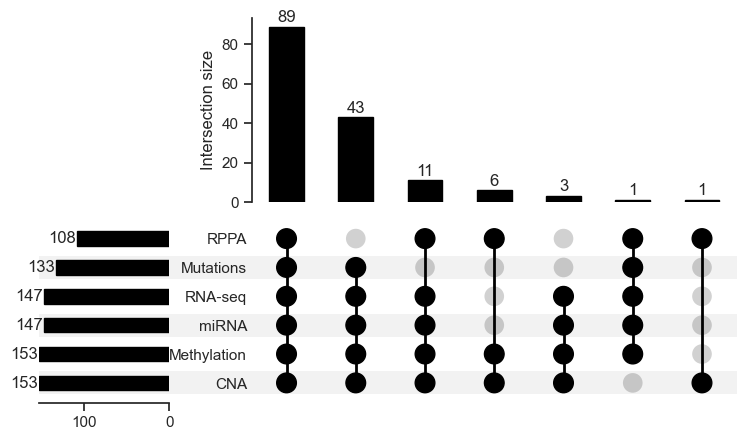

In [11]:
import upsetplot
from upsetplot import plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 5))
plot(upset_df, fig=fig, element_size=None, sort_by='cardinality', show_counts=True)
for ax in fig.axes:
    ax.grid(False)
plt.savefig('figures/upsetplot.svg', bbox_inches='tight')
plt.show()

### Survival and disease-free plots for all patients (no clusters)

In [12]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

In [13]:
final_benchmarking = pd.merge(methylation_new, cna_new, how='outer', left_index=True, right_index=True)
patients_list = final_benchmarking.index.tolist()

C:\Users\alepg\AppData\Local\Temp\ipykernel_19120\3100511783.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survival_data['Overall Survival Status'] = survival_data['Overall Survival Status'].str.split(':').str[0].astype(int)


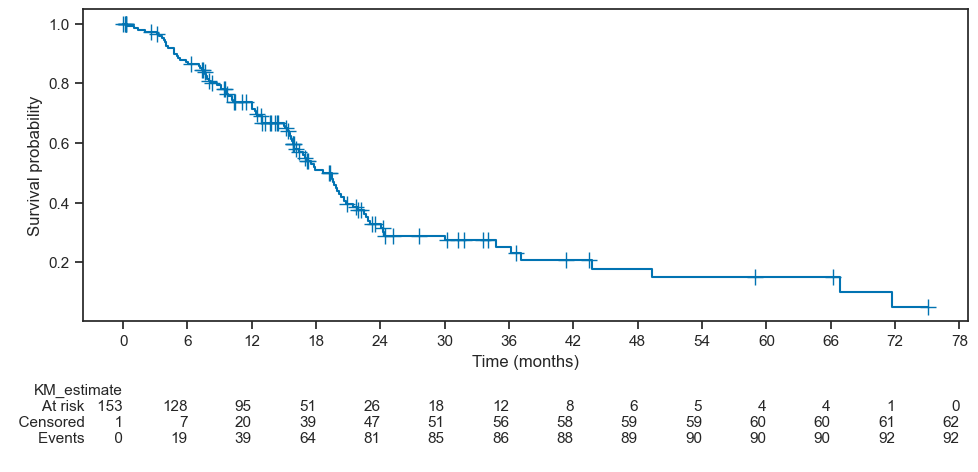

In [14]:
colorblind_palette = sns.color_palette("colorblind")
clinical_data = pd.read_csv('TCGA_raw_data/cancer_data_PAAD_clinical_data.tsv', sep='\t')
survival_data = clinical_data[['Patient ID', 'Overall Survival Status', 'Overall Survival (Months)']]
survival_data.set_index('Patient ID', inplace=True)
survival_data['Overall Survival Status'] = survival_data['Overall Survival Status'].str.split(':').str[0].astype(int)
survival_data = survival_data.loc[survival_data.index.isin(patients_list)]

kmf = KaplanMeierFitter()
kmf.fit(survival_data['Overall Survival (Months)'], event_observed=survival_data['Overall Survival Status'])
plt.figure(figsize=(10, 5))
ax = kmf.plot_survival_function(show_censors=True, legend=False, ci_show=False, color=colorblind_palette[0])
max_time = max(survival_data['Overall Survival (Months)'])
ticks = np.arange(0, max_time + 6, 6)
ax.set_xticks(ticks)
add_at_risk_counts(kmf, ax=plt.gca())
ax.set_ylabel('Survival probability')
ax.set_xlabel('Time (months)')
plt.tight_layout()
plt.savefig('figures/survival_all.svg', bbox_inches='tight')
plt.show()

C:\Users\alepg\AppData\Local\Temp\ipykernel_19120\119273938.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseasefree_data.dropna(how='any', axis=0, inplace=True)
C:\Users\alepg\AppData\Local\Temp\ipykernel_19120\119273938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseasefree_data['Disease Free Status'] = diseasefree_data['Disease Free Status'].str.split(':').str[0].astype(int)


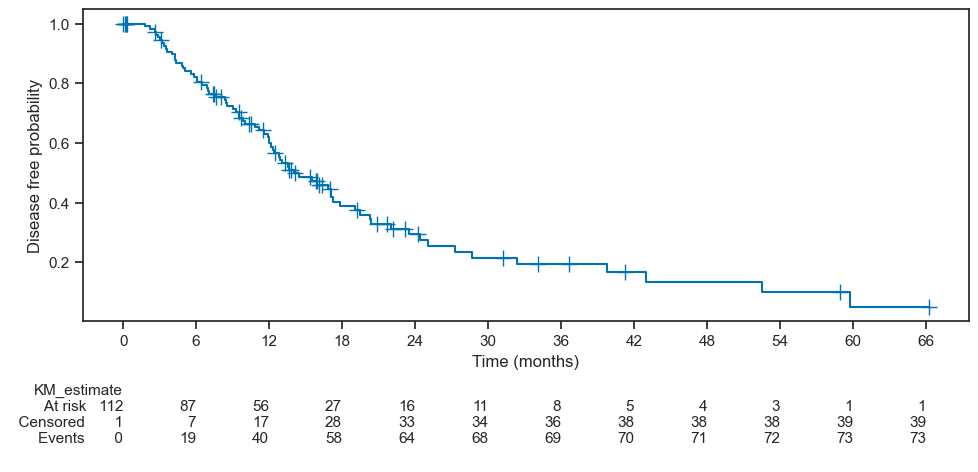

In [15]:
diseasefree_data = clinical_data[['Patient ID', 'Disease Free Status', 'Disease Free (Months)']]
diseasefree_data.set_index('Patient ID', inplace=True)
diseasefree_data.dropna(how='any', axis=0, inplace=True)
diseasefree_data['Disease Free Status'] = diseasefree_data['Disease Free Status'].str.split(':').str[0].astype(int)
diseasefree_data = diseasefree_data.loc[diseasefree_data.index.isin(patients_list)]

kmf = KaplanMeierFitter()
kmf.fit(diseasefree_data['Disease Free (Months)'], event_observed=diseasefree_data['Disease Free Status'])
plt.figure(figsize=(10, 5))
ax = kmf.plot_survival_function(show_censors=True, legend=False, ci_show=False, color=colorblind_palette[0])
max_time = max(diseasefree_data['Disease Free (Months)'])
ticks = np.arange(0, max_time + 3, 6)
ax.set_xticks(ticks)
add_at_risk_counts(kmf, ax=plt.gca())
ax.set_ylabel('Disease free probability')
ax.set_xlabel('Time (months)')
plt.tight_layout()
plt.savefig('figures/diseasefree_all.svg', bbox_inches='tight')
plt.show()